In [1]:
import gaiaDR4_pipeline as gp
from pathlib import Path
from tqdm import tqdm 
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

In [6]:
import importlib
importlib.reload(gp);

In [2]:
cwd = Path(os.getcwd()) / "../../my_code/dr4_prerelease"

In [3]:
#sourceIDs = find_file(tag="SingleStar_M035", sourceID_only=True)
source_ids = [ 1457486023639239296,  3937211745905473024]

In [7]:
for source_id in tqdm(source_ids):
    t_ast_days, psi_raw, ast_obs_raw, ast_err_raw, plx_factor_raw = gp.utils.extract_time_series(source_id, cwd)
    t_ast_yr_raw = t_ast_days / 365.25

    device = "cuda" if torch.cuda.is_available() else "cpu"
    gp.grid.run_grid_search_torch(cwd, source_id, t_ast_yr_raw, psi_raw, plx_factor_raw, ast_obs_raw * 1e3, ast_err_raw * 1e3, device=device,
                                  N_logP=500, N_ecc=30, N_phi=10, P_range=[10,1e4])

100%|██████████| 2/2 [00:23<00:00, 11.57s/it]


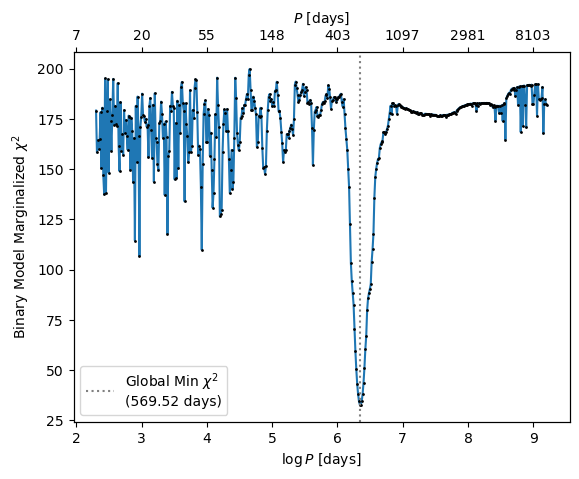

In [10]:
gp.utils.plot_grid_search_res(cwd, source_ids[0])